# <span style="color:red; font-size:30px"> Final Project Group 9 </span>

<font size = "5">

**By: Chad Himes (2774762), Aarin Singh (2758062), Sammy Paradise (2737621)**




<font size = "3">

This project explores which countries produce the highest-quality soccer (football) players using FIFA 22 player ratings as a proxy for real-world performance. Specifically, we compare player quality across both men’s and women’s datasets to determine whether similar nations dominate in each. This is relevant because understanding where top players originate from can provide insight into global talent development and inform scouting strategies for professional teams. 

Our analysis finds the top countries in terms of average player rating which for the men's side, Brazil, Italy, Portugal, Spain, and Croatia dominate the rankings, while on the female side the United States, Germany, England, France, Netherlands are at the top. We also looked at a comparison between the male and female ranking, and found that the relationship between them is extremely weak, or nonexistent.

The project starts by first describing the data and cleaning steps, followed by country-level aggregation, visualization, and simple comparative analysis.

<font size = "5">

Data Description:

<font size = "3">

We use two datasets from FIFA 22, one for male players and one for female players. Each row represents an individual player, each with variables including player name, overall rating, nationality, and many more specific in-game statistics. The male dataset contains 19,239 players across global club teams, while the female dataset contains 391 players representing national teams. This difference is important, as the men’s dataset includes a much broader range of players, while the women’s dataset consists only of top national-level talent, and some big name teams such as Italy are not even included.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [2]:
m_22 = pd.read_csv("2-FIFA/players_22.csv")
f_22 = pd.read_csv("2-FIFA/female_players_22.csv")

print("In the FIFA 22 dataset, there are" ,len(m_22), "male players and there are", len(f_22), "female players.")

In the FIFA 22 dataset, there are 19239 male players and there are 391 female players.


<font size = "4">

Data Cleaning:

<font size = "3">

To make the analysis more manageable, we reduced the dataset to a smaller set of columns: player ID, player name, overall rating, and nationality. This step removed unnecessary variables and cut down the overall size of the data, making it easier to work with and process. These columns were chosen because they capture the key information needed for this task. Player ID and name allow us to uniquely identify each player, overall rating provides a clear measure of player quality, and nationality allows us to group players by country. Keeping only these variables made it easier to compute summary statistics and compare results across different countries without extra, unrelated data getting in the way.

In [3]:
cleaned_m = m_22[["sofifa_id", "long_name", "overall",  "nationality_name"]]
cleaned_f = f_22[["sofifa_id", "long_name", "overall", "nationality_name"]]

<font size = "3">

Statistics for meaningful columns:

In [4]:
m_summary = cleaned_m.agg(
    mean_overall=("overall", "mean"),
    std_overall=("overall", "std"),
    min_overall=("overall", "min"),
    max_overall=("overall", "max"),
    median_overall=("overall", "median"),
    num_players=("overall", "count")
).round(2)

m_summary.head()


,overall
mean_overall,65.77
std_overall,6.88
min_overall,47.00
max_overall,93.00
median_overall,66.00


In [5]:
f_summary = cleaned_f.agg(
    mean_overall=("overall", "mean"),
    std_overall=("overall", "std"),
    min_overall=("overall", "min"),
    max_overall=("overall", "max"),
    median_overall=("overall", "median"),
    num_players=("overall", "count")
).round(2)

f_summary.head()

,overall
mean_overall,76.71
std_overall,5.74
min_overall,60.00
max_overall,92.00
median_overall,76.00


<font size = "5">

Grouping, Aggregating Statstics, and Merging:

<font size = "3">

To evaluate player quality by country, we grouped the data by nationality (setting the as_index parameter to false to retain the "nationality_name" col for future use) and compute two key statistics: the average overall rating and the number of players from each country. 

In [6]:
m_countrystats = cleaned_m.groupby("nationality_name", as_index= False).agg( 
    avg_overall = ("overall", "mean"), 
    num_players = ("overall", "count")).sort_values("avg_overall", ascending = False).round(2)


m_countrystats.head()

,nationality_name,avg_overall,num_players
146,Tanzania,74.00,1
93,Libya,73.33,3
108,Mozambique,73.00,4
27,Central African Republic,72.50,2
46,Egypt,72.25,12



<font size = "3">

After looking at the male dataset, we decided to apply a minimum threshold of 150 players per country to avoid bias from smaller countries with only a few high-rated players. Without this threshold, countries with very few players appeared overly strong (as shown above). The women’s dataset does not require a threshold, as each country is represented by a fixed number of players.

In [7]:
male_count_threshold = 150

filtered_m_countrystats = cleaned_m.groupby("nationality_name", as_index= False).agg(
    avg_overall = ("overall", "mean"),
    num_players = ("overall", "count")
).query("num_players >= @male_count_threshold").sort_values("avg_overall", ascending = False).round(2)

# Adding the ranks to a new col

m_ranks = []
for i in range(len(filtered_m_countrystats)):
    m_ranks = m_ranks + [i + 1]

filtered_m_countrystats["country_rank"] = m_ranks

filtered_m_countrystats["country_rank"] = filtered_m_countrystats["country_rank"].astype(int)

filtered_m_countrystats.head()

,nationality_name,avg_overall,num_players,country_rank
20,Brazil,70.85,897,1
80,Italy,69.98,338,2
124,Portugal,69.73,373,3
140,Spain,69.56,1086,4
37,Croatia,69.08,154,5


<font size = "3">

We used pd.merge to add the "avg_overall" and "country_rank" columns to the cleaned player dataframe by merging on "nationality_name". This brought the country-level statistics we calculated earlier back down to the individual player level. Players from countries that didn't meet the 150-player threshold simply received NaN values for those columns rather than being dropped. The result is a dataframe where each player is tagged with their country's average overall rating and rank. This sets us up to compare players across nationalities in our later analysis.

In [8]:
final_m_df = pd.merge(cleaned_m, filtered_m_countrystats[["nationality_name", "avg_overall", "country_rank"]], how = "left", on = "nationality_name")

In [9]:
# Repeated Same Process for Female 2022
# No threshold needed since all countries have exactly 23 players

f_countrystats = cleaned_f.groupby("nationality_name", as_index= False).agg(
    avg_overall = ("overall", "mean"),
    num_players = ("overall", "count")
).sort_values("avg_overall", ascending = False).round(2)

f_ranks = []

for i in range(len(f_countrystats)):
    f_ranks = f_ranks + [i + 1]

f_countrystats["country_rank"] = f_ranks

f_countrystats["country_rank"] = f_countrystats["country_rank"].astype(int)

f_countrystats.head(5)


,nationality_name,avg_overall,num_players,country_rank
16,United States,83.00,23,1
7,Germany,82.09,23,2
5,England,79.78,23,3
6,France,79.61,23,4
9,Netherlands,78.87,23,5


In [10]:
final_f_df = pd.merge(cleaned_f, f_countrystats[["nationality_name","avg_overall", "country_rank"]], how = "left", on = "nationality_name")

<font size = "3">


For future analysis, we also wanted to get a merged data frame with each countries male and female ranks, and find the best average rank. This allows us to have an overall metric for country skill without controlling for gender.

In [11]:
filtered_m_countrystats["male_country_rank"] = filtered_m_countrystats["country_rank"]
f_countrystats["female_country_rank"] = f_countrystats["country_rank"]

both_ranked = pd.merge(filtered_m_countrystats[["nationality_name", "male_country_rank"]], f_countrystats[["nationality_name", "female_country_rank"]], how = "left", on = "nationality_name")

both_ranked["combined_avg"] = (both_ranked["male_country_rank"] + both_ranked["female_country_rank"]) / 2

both_ranked = both_ranked.sort_values("combined_avg")

both_ranked.head()

,nationality_name,male_country_rank,female_country_rank,combined_avg
0,Brazil,1,7.0,4.0
6,France,7,4.0,5.5
3,Spain,4,8.0,6.0
7,Netherlands,8,5.0,6.5
2,Portugal,3,16.0,9.5


<font size = "5">

Results:

<font size = "3">

The following distributions show clear differences between the highest and lowest ranked countries. Top ranked countries tend to have a greater distribution of players with a variety of high and low overall ratings, indicating a stronger, more consistent talent pool. In contrast, lower ranked countries have right skewed distributions with a high concentration around lower ratings, suggesting less overall player quality.

This pattern highlights that the strongest soccer nations not only produce elite players but also maintain depth across their player base.

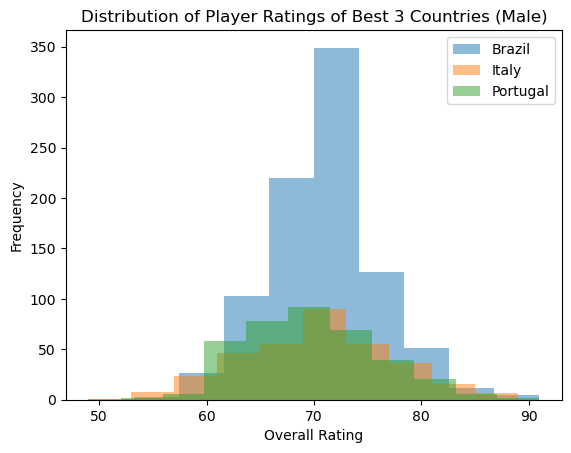

In [12]:

top3_mcountries = filtered_m_countrystats.head(3)["nationality_name"]


for country in top3_mcountries:
    current_country_df = final_m_df.query("nationality_name == @country")
    plt.hist(current_country_df["overall"], alpha=0.5)

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Player Ratings of Best 3 Countries (Male)")
plt.legend(top3_mcountries)
plt.show()

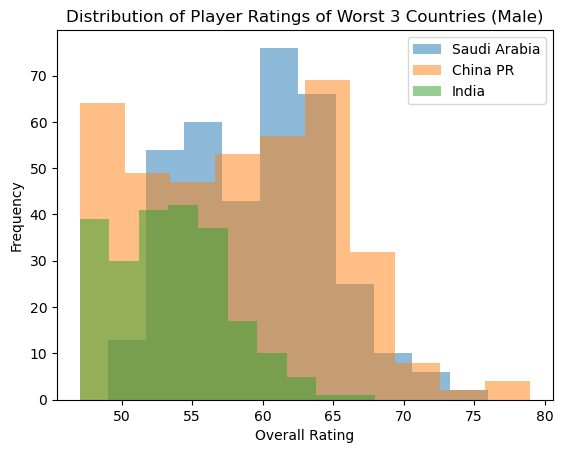

In [13]:

bottom3_mcountries = filtered_m_countrystats.tail(3)["nationality_name"]

for country in bottom3_mcountries:
    current_country_df = final_m_df.query("nationality_name == @country")
    plt.hist(current_country_df["overall"], alpha=0.5)

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Player Ratings of Worst 3 Countries (Male)")
plt.legend(bottom3_mcountries)
plt.show()

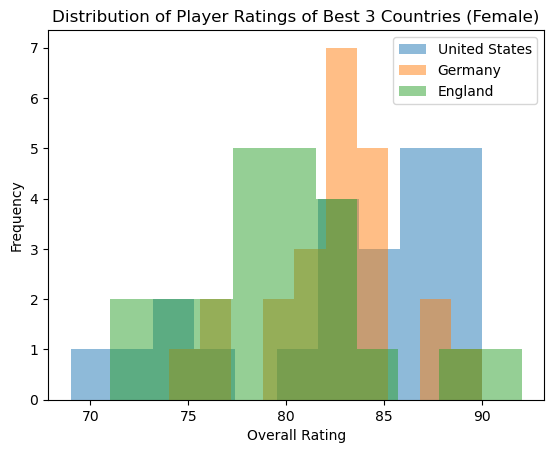

In [14]:

top3_fcountries = f_countrystats.head(3)["nationality_name"]


for country in top3_fcountries:
    current_country_df = final_f_df.query("nationality_name == @country")
    plt.hist(current_country_df["overall"], alpha=0.5)

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Player Ratings of Best 3 Countries (Female)")
plt.legend(top3_fcountries)
plt.show()


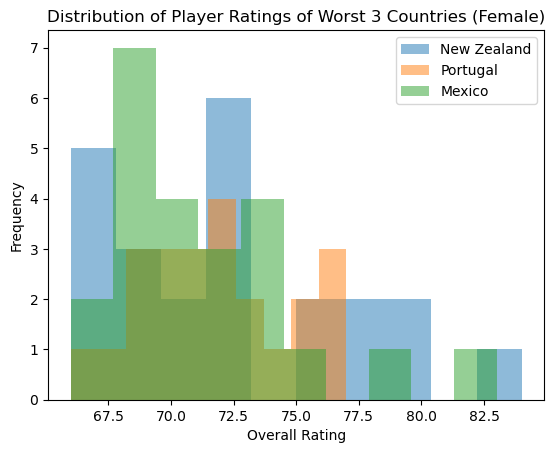

In [15]:

bottom3_fcountries = f_countrystats.tail(3)["nationality_name"]


for country in bottom3_fcountries:
    current_country_df = final_f_df.query("nationality_name == @country")
    plt.hist(current_country_df["overall"], alpha=0.5)

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Player Ratings of Worst 3 Countries (Female)")
plt.legend(bottom3_fcountries)
plt.show()


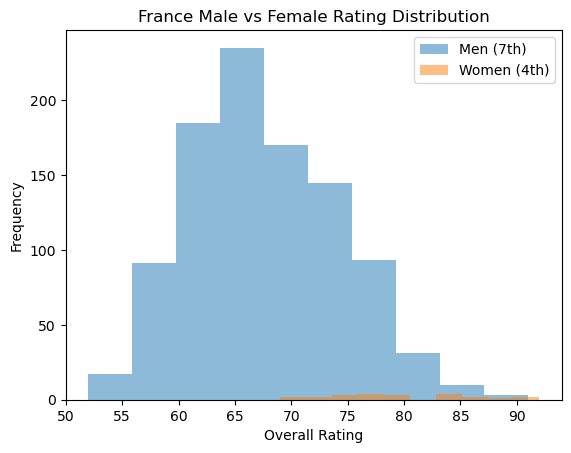

In [16]:
m_fr = cleaned_m.query("nationality_name == 'France'")
f_fr= cleaned_f.query("nationality_name == 'France'")

plt.hist(m_fr["overall"], alpha=0.5, label="Men (7th)")
plt.hist(f_fr["overall"], alpha=0.5, label="Women (4th)")

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("France Male vs Female Rating Distribution")
plt.legend()
plt.show()

<font size = "3">


Comparing men’s and women’s player distributions directly is challenging due to the large difference in dataset size (as shown above). The men’s dataset includes thousands of players, while the women’s dataset includes only national team players. To make a more balanced comparison, we restricted the men’s data to the top 23 players (matching the number of players in the female dataset). This provided a more meaningful comparison of player quality between the two groups.

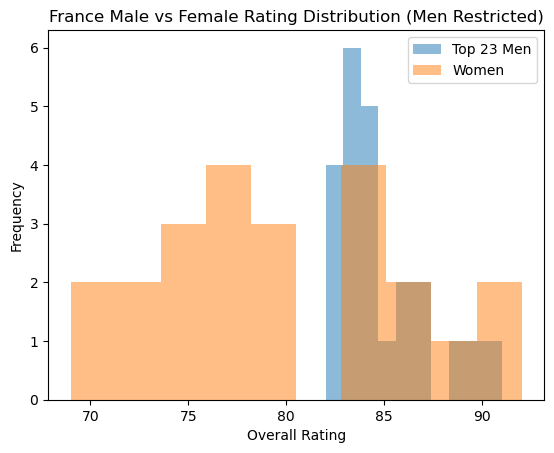

In [17]:
# Let's see what that looks like

top23_fr_m = m_fr.sort_values("overall", ascending= False).head(23)

plt.hist(top23_fr_m["overall"], alpha=0.5, label="Top 23 Men")
plt.hist(f_fr["overall"], alpha=0.5, label="Women")

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("France Male vs Female Rating Distribution (Men Restricted)")
plt.legend()
plt.show()

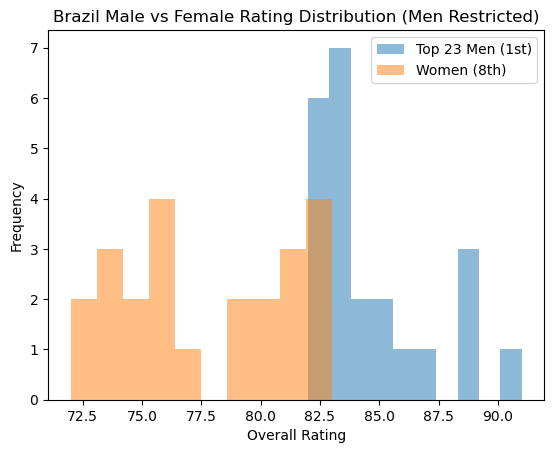

In [18]:
# Doing same for Brazil

m_br = cleaned_m.query("nationality_name == 'Brazil'")
f_br= cleaned_f.query("nationality_name == 'Brazil'")

top23_br_m = m_br.sort_values("overall", ascending= False).head(23)

plt.hist(top23_br_m["overall"], alpha=0.5, label="Top 23 Men (1st)")
plt.hist(f_br["overall"], alpha=0.5, label="Women (8th)")

plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("Brazil Male vs Female Rating Distribution (Men Restricted)")
plt.legend()
plt.show()

<font size = "3">

Additionally, we wanted to look to see how the average overall changes as country rank increases.

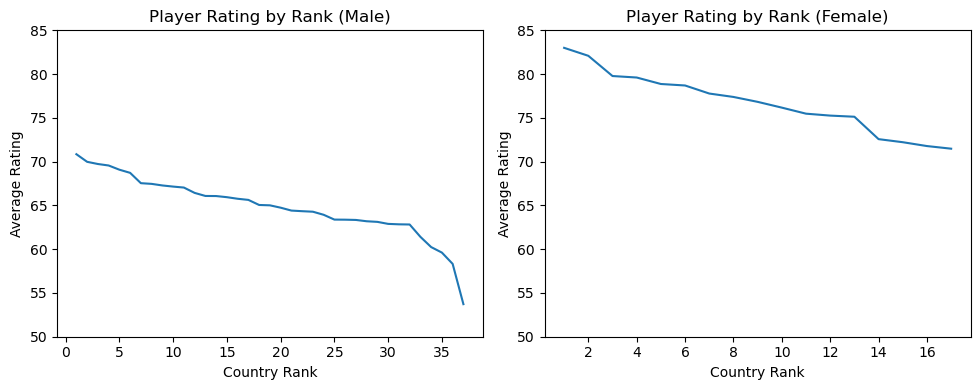

In [19]:
fig, subplt = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

subplt[0].plot(filtered_m_countrystats["country_rank"], filtered_m_countrystats["avg_overall"])
subplt[0].set_xlabel("Country Rank")
subplt[0].set_ylabel("Average Rating")
subplt[0].set_title("Player Rating by Rank (Male)")
subplt[0].set_ylim(50, 85)

subplt[1].plot(f_countrystats["country_rank"], f_countrystats["avg_overall"])
subplt[1].set_xlabel("Country Rank")
subplt[1].set_ylabel("Average Rating")
subplt[1].set_title("Player Rating by Rank (Female)")
subplt[1].set_ylim(50, 85)


plt.tight_layout()
plt.show()

<font size = "3">

As expected, these plots show how average player ratings decline as country rank decreases for both men and women. In both cases, higher ranked countries have noticeably higher average ratings, with a gradual decline as rank increases.

However, the decline appears steeper in the men’s dataset, suggesting a wider gap between top and lower-ranked countries. In contrast, the women’s ratings appear more compressed, likely due to the smaller and more selective dataset. This indicates that while top countries perform well in both groups, the distribution of talent differs between men’s and women’s soccer.

<font size = "3">

We then wanted to look and see if there exists any relationship between a country's male rank and female rank.

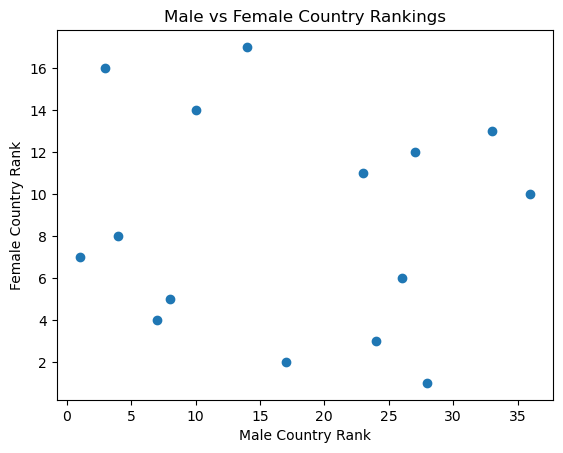

In [20]:
plt.scatter(both_ranked["male_country_rank"],both_ranked["female_country_rank"])
plt.xlabel("Male Country Rank")
plt.ylabel("Female Country Rank")
plt.title("Male vs Female Country Rankings")
plt.show()

<font size = "3">

This suggests that countries successful in men’s soccer are not necessarily dominant in women’s soccer. However, this result should be interpreted cautiously, as differences in dataset structure can lead to bias in this comparison.


<font size = "5">

Discussion:

<font size = "3">

Overall, our analysis shows that the countries producing the highest-rated players differ notably between men’s and women’s soccer. On the men’s side, traditional football powerhouses such as Brazil, Spain, and Italy rank highly, reflecting both strong development systems and deep player pools. For women, however, countries like the United States, Germany, and England lead the rankings, suggesting that investment, infrastructure, and cultural support for women’s soccer play a major role in shaping success. We also observed that top-ranked countries tend to have not only elite players but also greater depth, as seen in the wider distribution of player ratings. 

A key takeaway from this project is that success in men’s soccer does not strongly translate to success in women’s soccer. The weak relationship between male and female country rankings highlights how differently the two systems develop globally. Additionally, dataset differences due to the broader scope of the men’s data versus the more selective women’s data affect comparisons and should be considered when interpreting our results. Overall, this project emphasizes that talent development is multifaceted and varies significantly across countries and between men’s and women’s soccer.